## get all similarities

We load the label name or description of all the nodes in the AI graph.


In [1]:
embedding_model_id = "all-MiniLM-L6-v2"
#embedding_model_id = "BAAI/bge-large-en-v1.5"



from sentence_transformers import SentenceTransformer, util
import torch

import pandas as pd



embedding_model = SentenceTransformer(embedding_model_id, device="cuda:1" if torch.cuda.device_count()>1 else "cuda:0")


/home/sondre/miniconda3/envs/upcast/lib/python3.10/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


In [2]:
DATASET="dbp_restricted"
#MODE = "label"
MODE= "description"

In [3]:
if DATASET=="ccs_v2":
    # ccs v2 terms

    from metadata_schemas.acm_ccs_v2 import CCS_HIERARCHY as ai_terms
    ai_terms = str(ai_terms).split("'")[1::2]
    ai_term_embedding = embedding_model.encode(ai_terms)

if DATASET=="dbp_restricted":
    # dbpedia ai restricted top3

    ai_terms = pd.read_csv("dbpedia_aitax_restricted_top3.csv", index_col=0)
    print(ai_terms.head())
    ai_term_embedding = embedding_model.encode(ai_terms[MODE].to_list())
    
    ai_texts = ai_terms["description"].to_list()
    ai_terms = ai_terms["label"].to_list()

                                    label  number_of_correct_in_topk  \
0             Natural language processing                          3   
1                 Artificial intelligence                          3   
2                     Machine translation                          3   
3  Knowledge representation and reasoning                          3   
4               Computational linguistics                          3   

                                         description  
0  Natural language processing (NLP) is a subfiel...  
1  Artificial intelligence (AI) is intelligence—p...  
2  Machine translation, sometimes referred to by ...  
3  Knowledge representation and reasoning (KRR, K...  
4  Computational linguistics is an interdisciplin...  


In [4]:
from dataset_loader import Arxiv_HF_datasets
ahd = Arxiv_HF_datasets()
ahd.prepare()
hf_df, arx_df = ahd.sample_subsets(1103)
hf_df = hf_df.set_index("modelId")


/home/sondre/profile/llmdap/profiler/dataset_loader.py:448: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  self.arx = self.arx[self.arx["bin"]>=bin_range[0]][self.arx["bin"]<=bin_range[1]]


In [5]:
hf_dict, arx_dict = ahd.get_dict_format(1103)

In [6]:
arx_df

,title,categories,abstract,submission_date,authors_parsed,bin
id,,,,,,
2203.15366,Face segmentation: A comparison between visibl...,cs.CV,Face segmentation is a first step for face b...,2022-03-29 09:02:45,"[['Mekyska', 'Jiri', ''], ['Espinosa-Duró', 'V...",2022.03
2204.00062,SimPO: Simultaneous Prediction and Optimization,cs.LG,Many machine learning (ML) models are integr...,2022-03-31 20:01:36,"[['Zhang', 'Bing', ''], ['Ong', 'Yuya Jeremy',...",2022.03
2203.05340,Domain Generalization via Shuffled Style Assem...,cs.CV,With diverse presentation attacks emerging c...,2022-03-10 12:44:05,"[['Wang', 'Zhuo', ''], ['Wang', 'Zezheng', '']...",2022.03
2203.01193,VAE-iForest: Auto-encoding Reconstruction and ...,cs.CV,"In road monitoring, it is an important issue...",2022-03-02 15:47:36,"[['Yasuno', 'Takato', ''], ['Fujii', 'Junichir...",2022.03
2203.16130,Sensor Data Validation and Driving Safety in A...,cs.CV,Autonomous driving technology has drawn a lo...,2022-03-30 08:17:14,"[['Zhang', 'Jindi', '']]",2022.03
...,...,...,...,...,...,...
2509.13833,Track Any Motions under Any Disturbances,cs.RO,A foundational humanoid motion tracker is expe...,2025-09-17 08:58:55,"[['Zhang', 'Zhikai', ''], ['Guo', 'Jun', ''], ...",2025.09
2509.08743,"Parallel, Asymptotically Optimal Algorithms fo...",cs.RO,The Moving Target Traveling Salesman Problem (...,2025-09-10 16:34:12,"[['Bhat', 'Anoop', ''], ['Gutow', 'Geordan', '...",2025.09
2509.05188,SL-SLR: Self-Supervised Representation Learnin...,cs.CV,Sign language recognition (SLR) is a machine l...,2025-09-05 15:38:19,"[['Madjoukeng', 'Ariel Basso', ''], ['Fink', '...",2025.09


In [7]:
hf_df["text"] = ""
arx_df["text"] = ""

for modelId in hf_df.index:
    hf_df.loc[modelId, "text"] = hf_dict[modelId.replace("/", "__")]
for paperid in arx_df.index:
    arx_df.loc[paperid, "text"] = arx_dict[paperid]


### embedd

In [8]:
arx_strings = arx_df["text"].to_list()
paper_embeddings = embedding_model.encode(arx_strings)
model_embeddings = embedding_model.encode(hf_df["text"].to_list())


### standardize format embedding?

In [9]:
paper_embeddings.shape

(47429, 384)

In [10]:
mean_embedding_difference = (paper_embeddings.mean(axis=0) - model_embeddings.mean(axis=0))


In [11]:
standardize_factor=0
paper_embeddings = paper_embeddings-mean_embedding_difference*standardize_factor/2
model_embeddings = model_embeddings+mean_embedding_difference*standardize_factor/2

### calculate similarities

In [12]:

arx_similarities = util.cos_sim(paper_embeddings, ai_term_embedding)
hf_similarities = util.cos_sim(model_embeddings, ai_term_embedding)



# make plots

In [13]:
import torch
k = 10 # try out differnt values

def get_topk_indices_per_row(tensor: torch.Tensor, k: int = 5) -> torch.Tensor:
    """
    Returns the column indices of the top-k values in each row of the input tensor.

    Args:
        tensor (torch.Tensor): A 2D tensor of shape (num_rows, num_columns).
        k (int): Number of top values to retrieve per row.

    Returns:
        torch.Tensor: A 2D tensor of shape (num_rows, k) containing the column indices.
    """
    _, indices = torch.topk(tensor, k=k, dim=1)
    return indices

top_k_topics_per_paper = get_topk_indices_per_row(arx_similarities, k=k)

In [14]:
from matplotlib import pyplot as plt
def plot_term(term,k, min_examples=100):

    term_index = ai_terms.index(term)

    arx_topk = get_topk_indices_per_row(arx_similarities, k=k)
    arx_mask = (arx_topk==term_index).any(axis=1)

    hf_topk = get_topk_indices_per_row(hf_similarities, k=k)
    hf_mask = (hf_topk==term_index).any(axis=1)


    hf_df["mask"] = hf_mask
    arx_df["mask"] = arx_mask

    hf_dates = hf_df[hf_df["mask"]]["createdAt"]
    arx_dates = arx_df[arx_df["mask"]]["submission_date"]


    if len(arx_dates)+len(hf_dates)<min_examples:
        return
    plt.hist(arx_dates, bins=20, label="arx")
    plt.hist(hf_dates, bins=20, alpha=0.6, label="HF")
    plt.title(term)
    plt.legend()
    plt.show()

In [15]:
#for term in ai_terms:
#    plot_term(term, 15, 500)


# cluster etc

In [16]:
umap_min_dist = 0.0
umap_neighbors = 15
umap_dimensions = 15
hbd_min_cluster = 10

from umap import UMAP
from hdbscan import HDBSCAN


In [17]:

umap_model = UMAP(n_neighbors=umap_neighbors, n_components=umap_dimensions, min_dist=umap_min_dist, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=hbd_min_cluster, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

In [18]:
# Pre-reduce embeddings for visualization purposes
reduced_embeddings = UMAP(n_neighbors=umap_neighbors, n_components=2, min_dist=0.0, metric='cosine', random_state=42).fit_transform(ai_term_embedding)

/home/sondre/miniconda3/envs/upcast/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/sondre/miniconda3/envs/upcast/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [19]:
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, TextGeneration

# KeyBERT
keybert = KeyBERTInspired()

# MMR
mmr = MaximalMarginalRelevance(diversity=0.3)

# Text generation with Llama 2
#llama2 = TextGeneration(generator, prompt=prompt)

# All representation models
representation_model = {
    "KeyBERT": keybert,
    #"Llama2": llama2,
    "MMR": mmr,
}

In [20]:
from bertopic import BERTopic

topic_model = BERTopic(

  # Sub-models
  embedding_model=embedding_model,
  umap_model=umap_model,
  hdbscan_model=hdbscan_model,
  representation_model=representation_model,

  # Hyperparameters
  top_n_words=10,
  verbose=True
)

# Train model
#topics, probs = topic_model.fit_transform(ai_texts, ai_term_embedding)
topics, probs = topic_model.fit_transform(ai_terms, ai_term_embedding)

2025-10-02 14:43:38,601 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-02 14:43:50,699 - BERTopic - Dimensionality - Completed ✓
2025-10-02 14:43:50,703 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-02 14:43:50,814 - BERTopic - Cluster - Completed ✓
2025-10-02 14:43:50,819 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-02 14:43:53,084 - BERTopic - Representation - Completed ✓


In [21]:
keybert_labels = ["_".join(labels[:5]) for labels in topic_model.get_topic_info()["KeyBERT"].values]
topic_model.set_topic_labels(keybert_labels)

In [22]:
# Show topics
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,CustomName,Representation,KeyBERT,MMR,Representative_Docs
0,-1,705,-1_image_model_language_analysis,image_detection_imaging_processing_algorithm,"[image, model, language, analysis, map, error,...","[image, detection, imaging, processing, algori...","[image, map, detection, inference, cognitive, ...","[Digital image processing, Language model, Ima..."
1,0,137,0_learning_machine_decision_tree,classifiers_classifier_classification_supervis...,"[learning, machine, decision, tree, classifica...","[classifiers, classifier, classification, supe...","[tree, classification, classifier, vector, sup...","[Decision tree learning, Learning curve (machi..."
2,1,96,1_neural_network_networks_deep,neural_networks_backpropagation_layer_network,"[neural, network, networks, deep, backpropagat...","[neural, networks, backpropagation, layer, net...","[neural, backpropagation, recurrent, hebbian, ...","[Neural Network Intelligence, Artificial neura..."
3,2,88,2_analysis_component_data_principal,pca_analysis_data_dimensionality_components,"[analysis, component, data, principal, reducti...","[pca, analysis, data, dimensionality, componen...","[dimensionality, discriminant, correspondence,...","[Component analysis (statistics), Principal co..."
4,3,83,3_carlo_monte_sampling_transport,monte_carlo_stochastic_markov_sampling,"[carlo, monte, sampling, transport, metropolis...","[monte, carlo, stochastic, markov, sampling, m...","[carlo, monte, sampling, transport, metropolis...","[Markov chain Monte Carlo, Monte Carlo method,..."
5,4,81,4_parsing_grammar_language_linguistics,parsing_parser_treebank_syntactic_linguistic,"[parsing, grammar, language, linguistics, natu...","[parsing, parser, treebank, syntactic, linguis...","[parsing, grammar, linguistics, semantic, lexi...","[Natural language processing, Syntactic parsin..."
6,5,67,5_least_squares_regression_linear,regression_squares_linear_regularization_nonli...,"[least, squares, regression, linear, generaliz...","[regression, squares, linear, regularization, ...","[regression, generalized, additive, hall, pane...","[Generalized least squares, Least squares, Lin..."
7,6,63,6_interpolation_spline_bézier_polynomial,interpolation_spline_smoothing_discretization_...,"[interpolation, spline, bézier, polynomial, cu...","[interpolation, spline, smoothing, discretizat...","[interpolation, spline, bézier, curve, surface...","[Linear interpolation, Spline interpolation, I..."
8,7,61,7_intelligence_artificial_ai_cognitive,ai_computational_algorithmic_intelligence_know...,"[intelligence, artificial, ai, cognitive, arch...","[ai, computational, algorithmic, intelligence,...","[intelligence, ai, cognitive, architecture, al...","[Generative artificial intelligence, Artificia..."
9,8,61,8_knowledge_ontology_schema_semantic,knowledge_semantic_relational_ontology_semantics,"[knowledge, ontology, schema, semantic, body, ...","[knowledge, semantic, relational, ontology, se...","[knowledge, ontology, schema, semantic, concep...","[Body of knowledge, Knowledge graph, Semantic ..."


In [23]:
topic_model.visualize_documents(ai_terms, reduced_embeddings=reduced_embeddings, hide_annotations=True, hide_document_hover=False, custom_labels=True)

# plot aggregated plots



In [24]:
term_and_topics = pd.DataFrame(ai_terms, columns=["term"])
term_and_topics["topic"] = topics

topic_names = topic_info[["Topic", "CustomName"]].set_index("Topic")


In [25]:
from matplotlib import pyplot as plt
def plot_topic(topic_nr,k, min_examples=100):

    term_indices = term_and_topics[term_and_topics["topic"]==topic_nr].index.to_list()

    arx_topk = get_topk_indices_per_row(arx_similarities, k=k)
    arx_mask = (arx_topk == term_indices[0])
    for idx in term_indices[1:]:
        arx_mask += (arx_topk == idx)

    hf_topk = get_topk_indices_per_row(hf_similarities, k=k)
    hf_mask = (hf_topk == term_indices[0])
    for idx in term_indices[1:]:
        hf_mask += (hf_topk == idx)


    hf_df["mask"] = hf_mask
    arx_df["mask"] = arx_mask

    hf_dates = hf_df[hf_df["mask"]]["createdAt"]
    arx_dates = arx_df[arx_df["mask"]]["submission_date"]


    if len(arx_dates)+len(hf_dates)<min_examples:
        return
    plt.hist(arx_dates, bins=20, label="arx;"+str(len(arx_dates)))
    plt.hist(hf_dates, bins=20, alpha=0.6, label="HF;"+str(len(hf_dates)))
    plt.title(str(topic_nr)+":"+topic_names.loc[topic_nr]["CustomName"])
    plt.legend()
    plt.show()

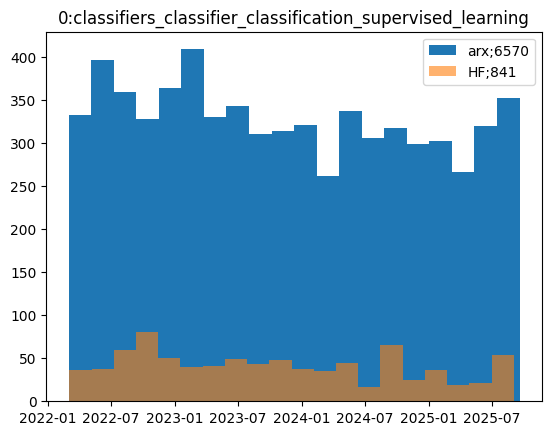

In [27]:
for topic_nr in range(1):
    plot_topic(topic_nr, k=1, min_examples=15)

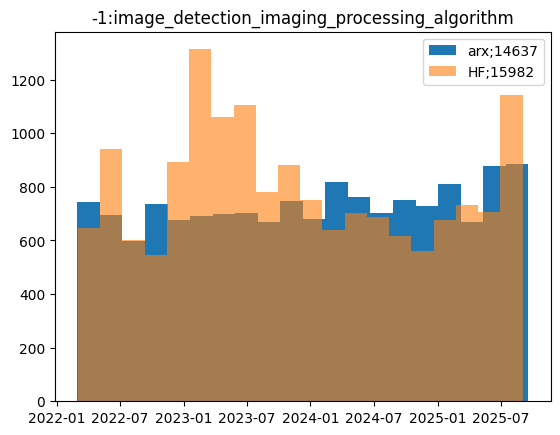

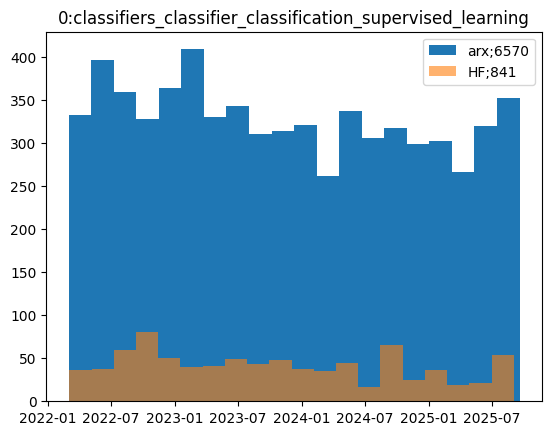

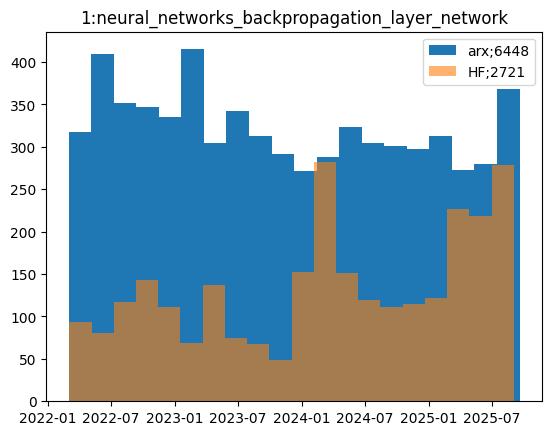

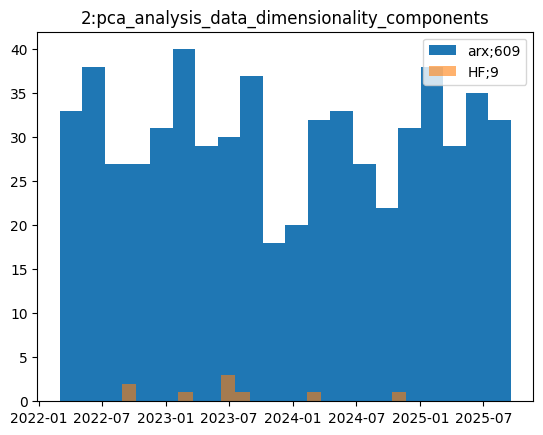

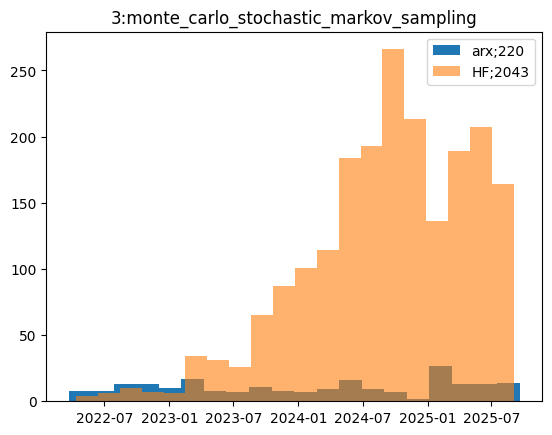

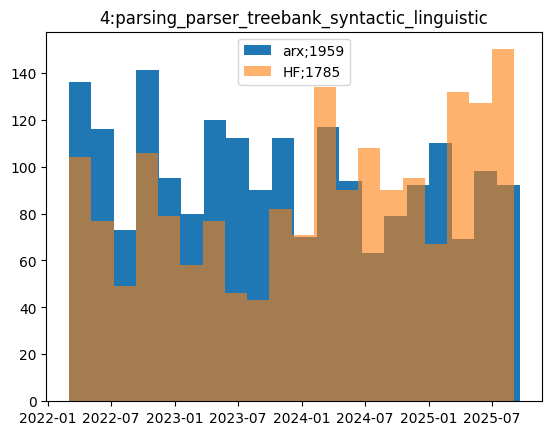

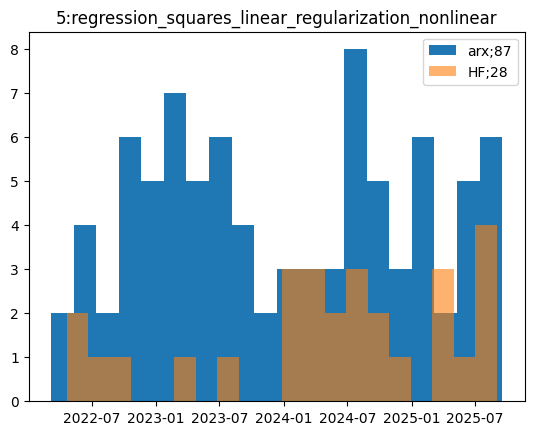

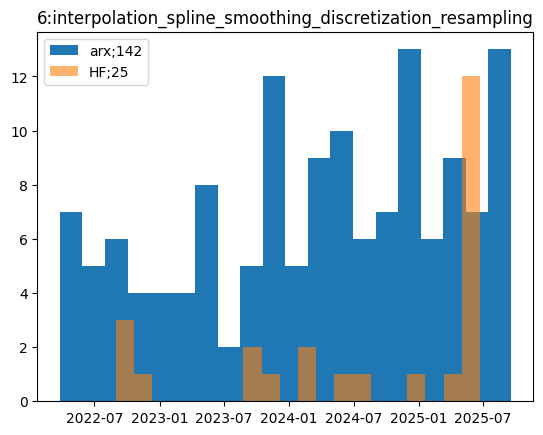

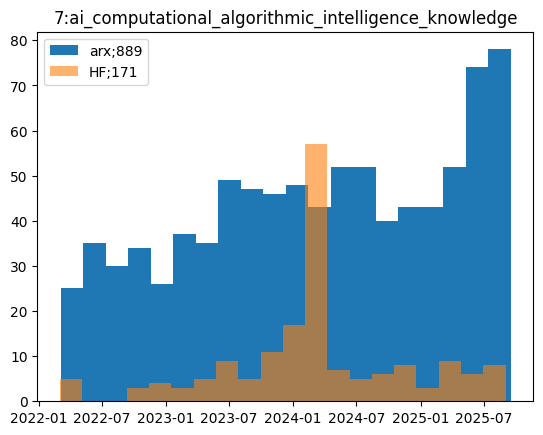

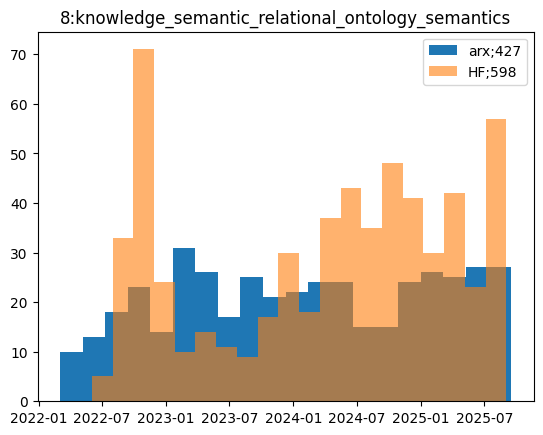

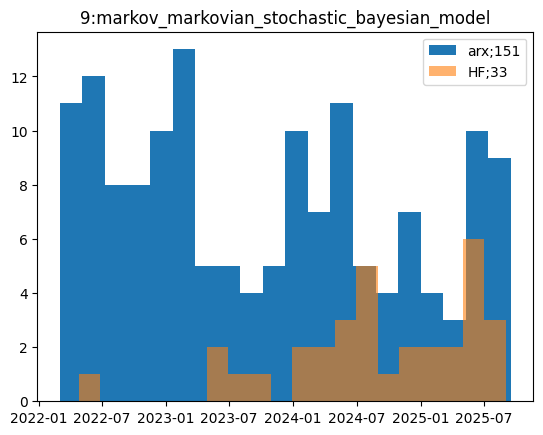

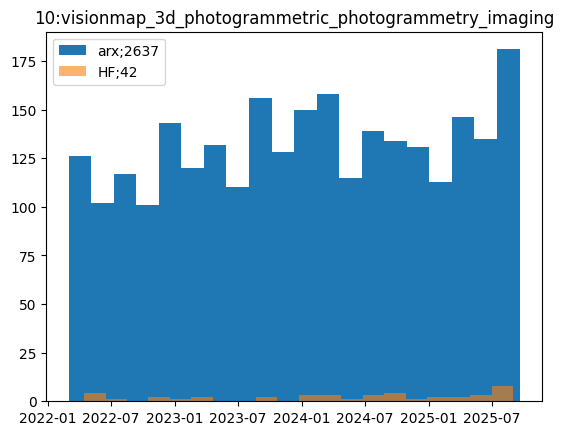

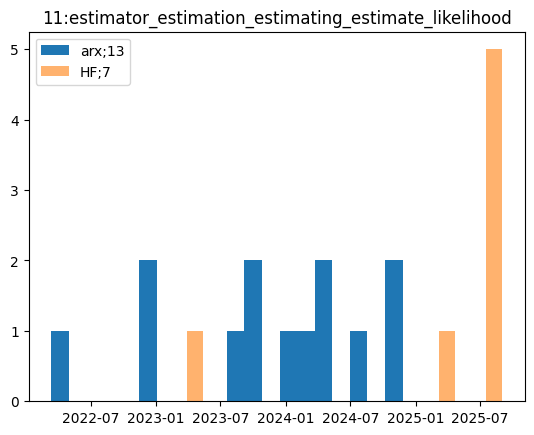

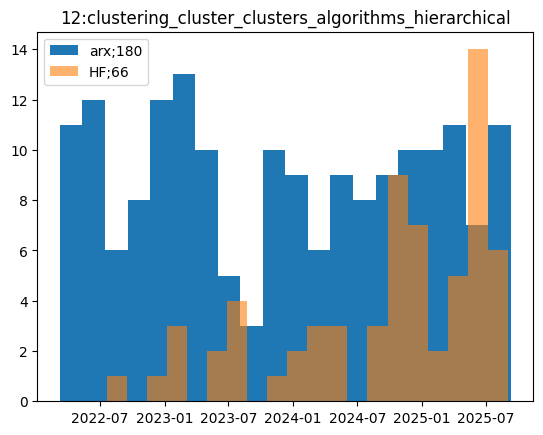

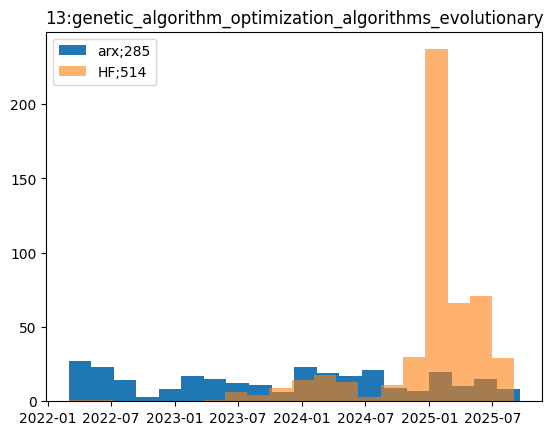

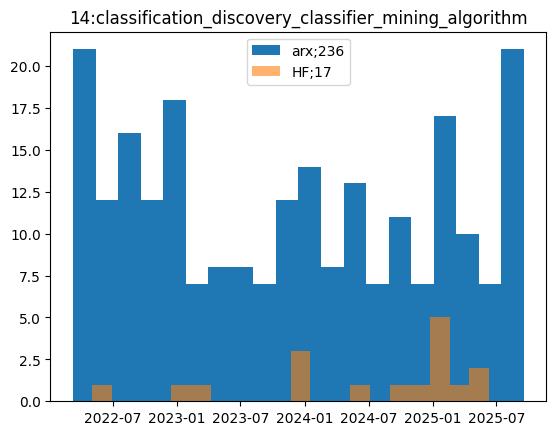

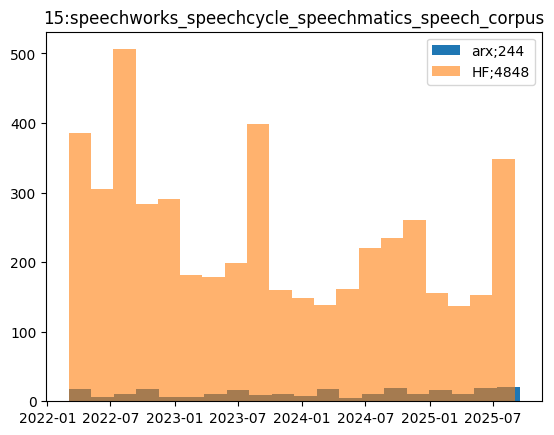

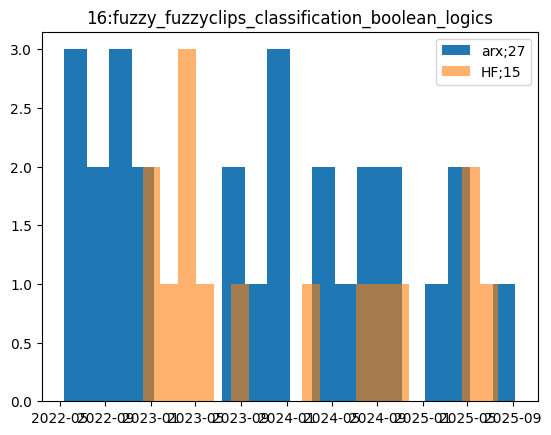

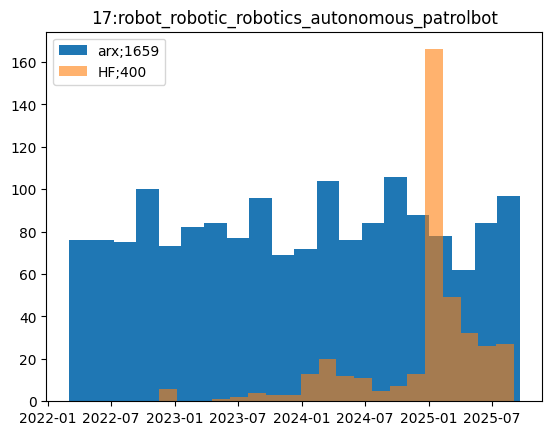

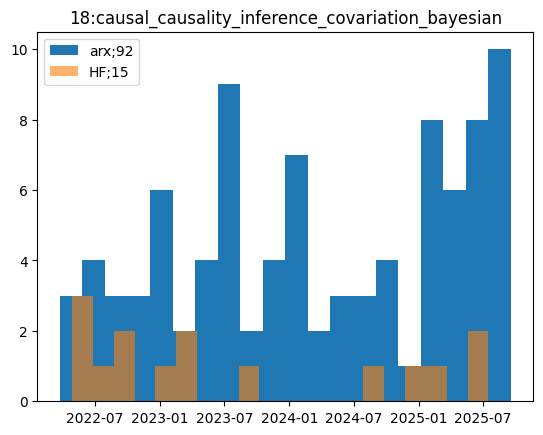

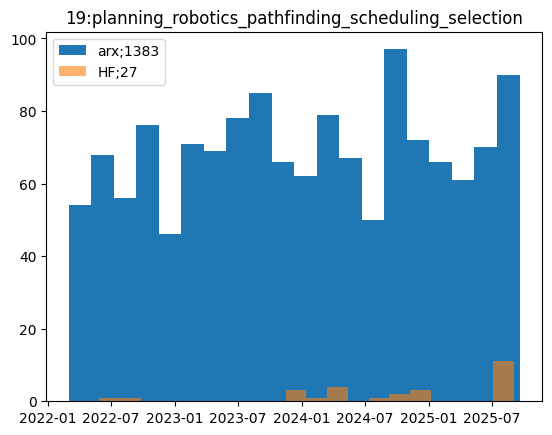

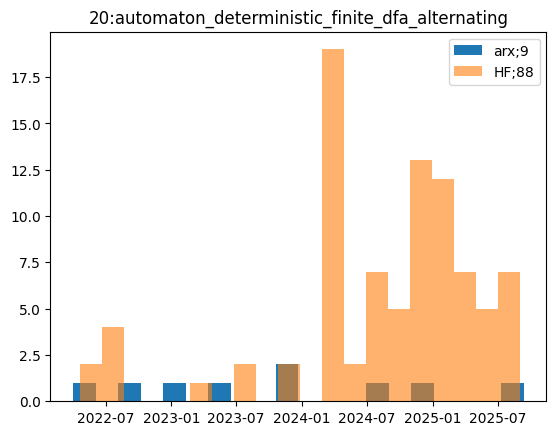

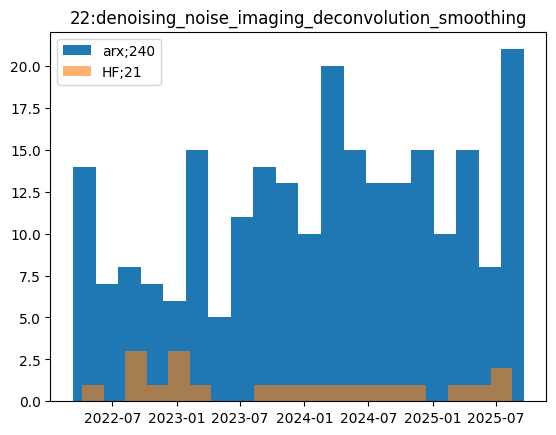

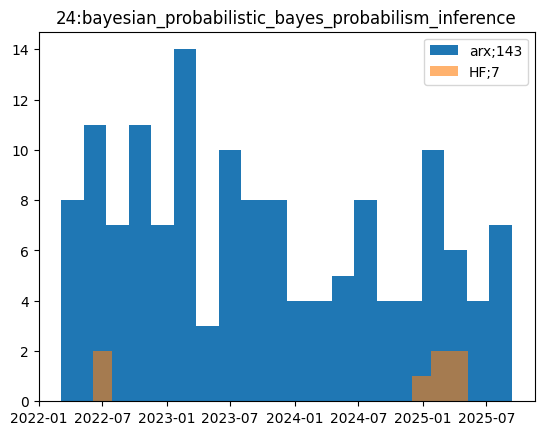

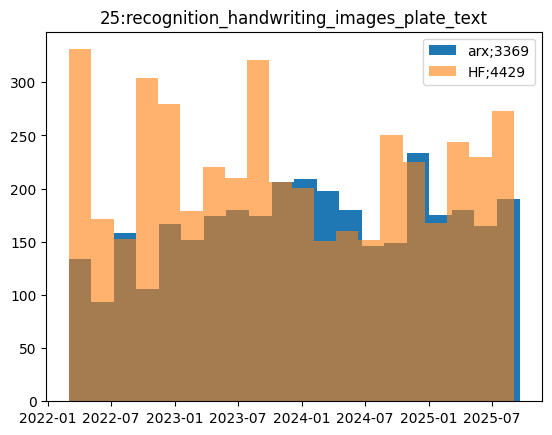

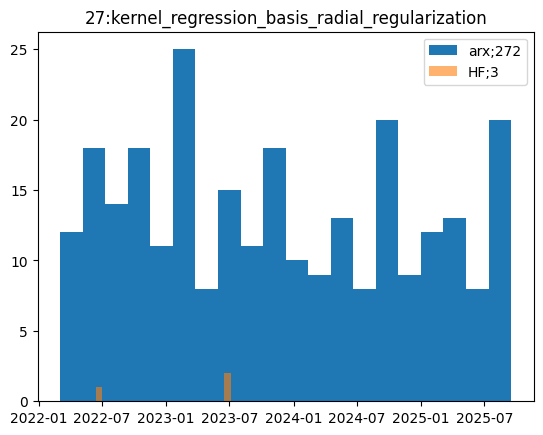

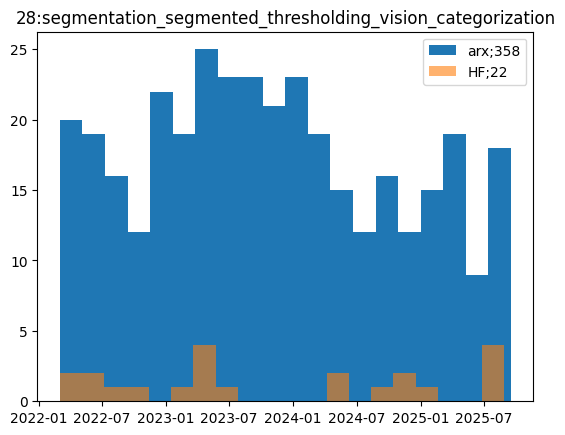

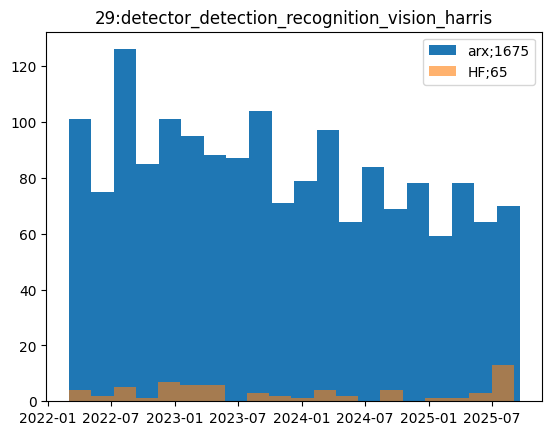

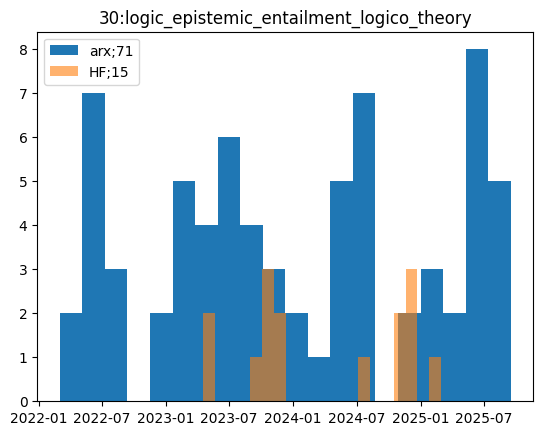

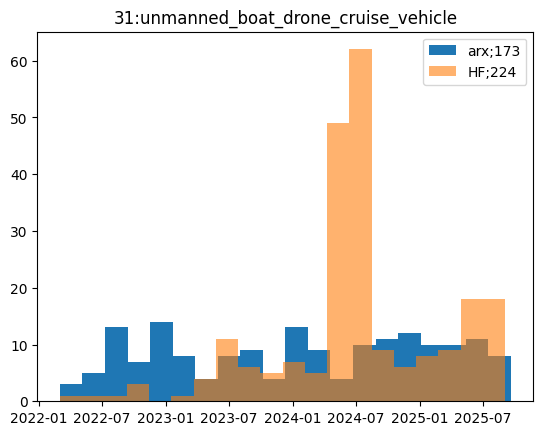

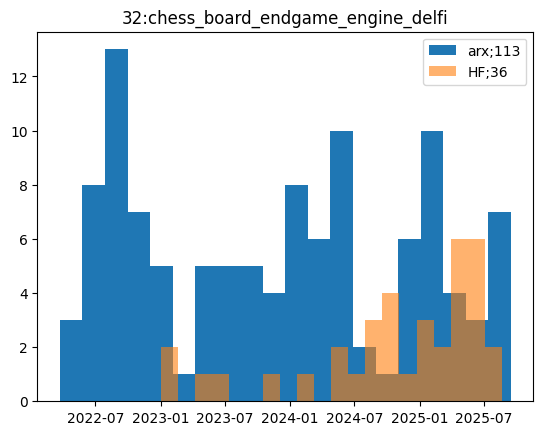

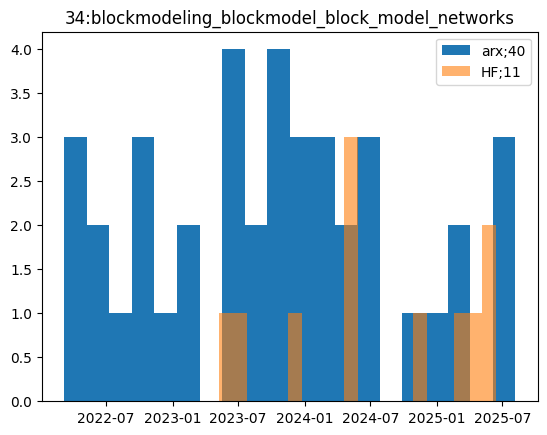

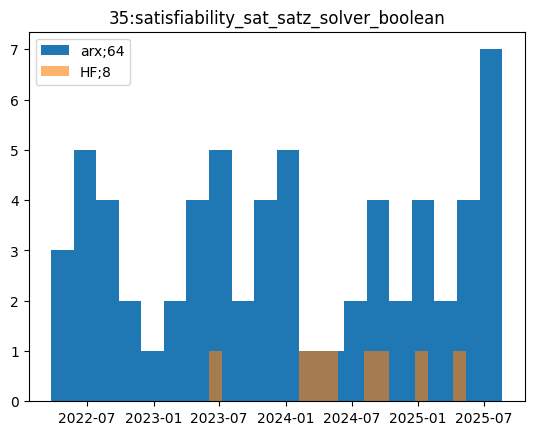

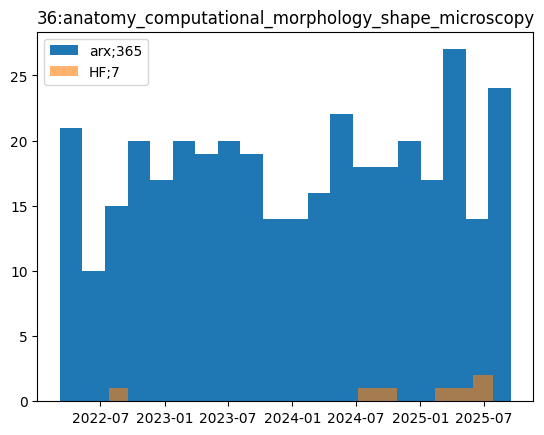

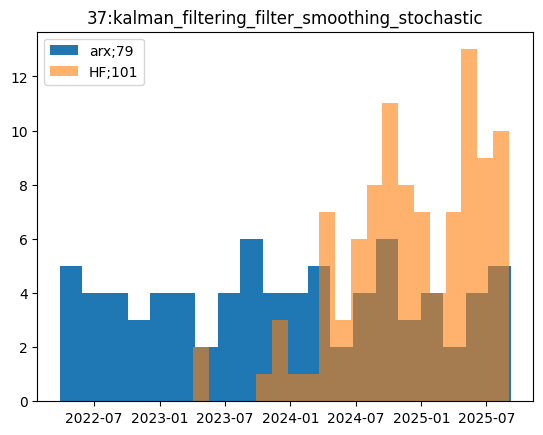

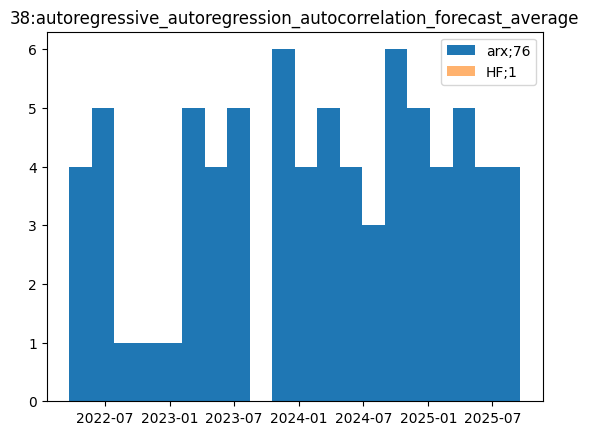

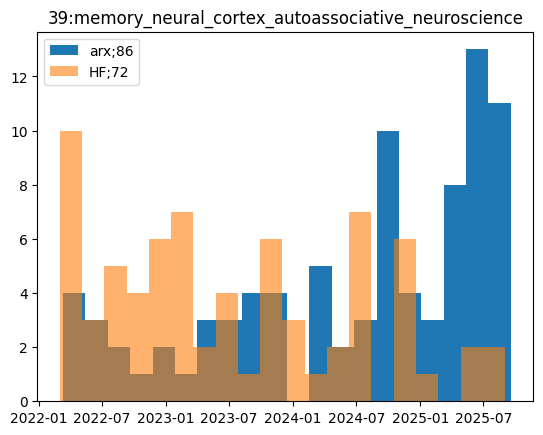

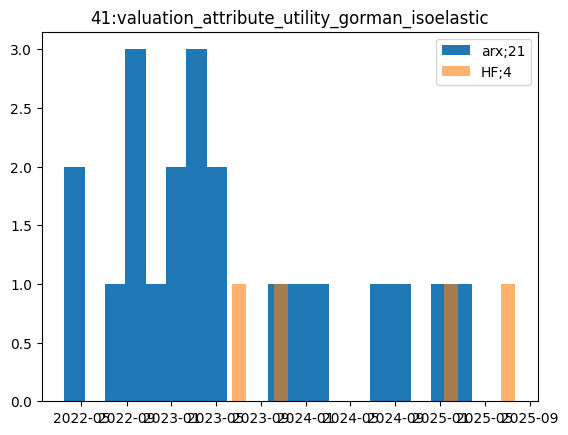

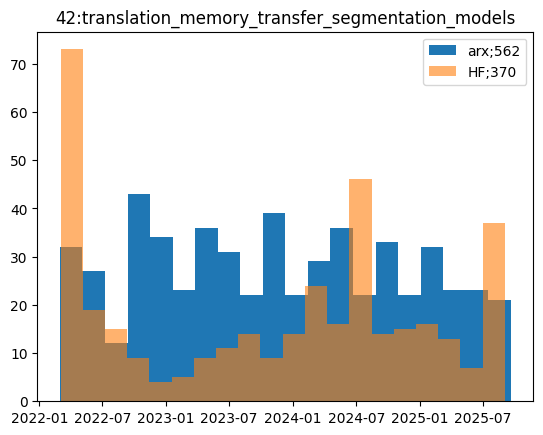

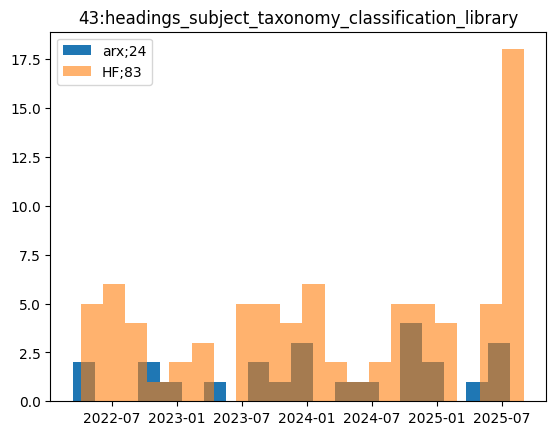

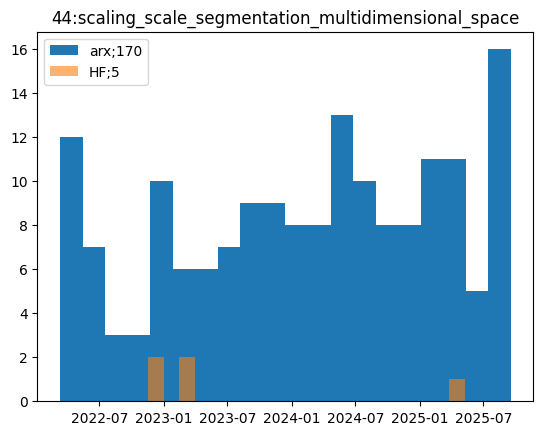

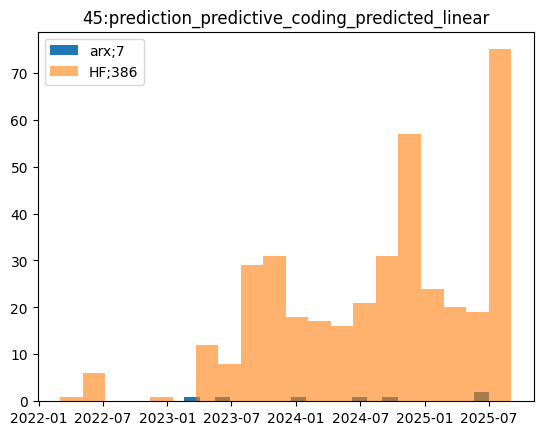

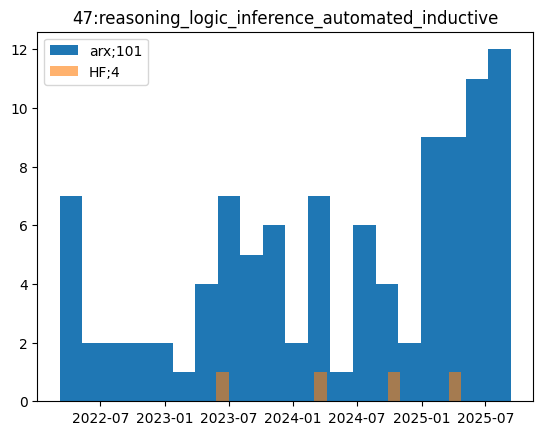

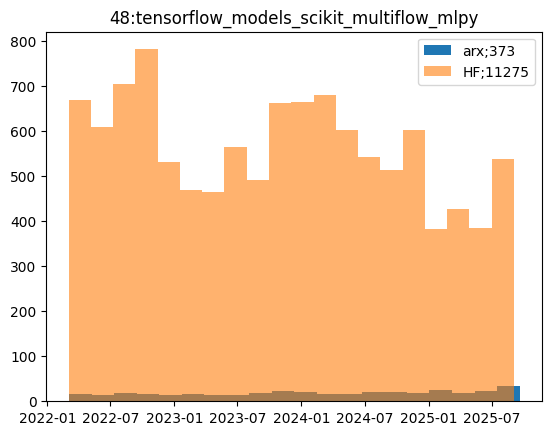

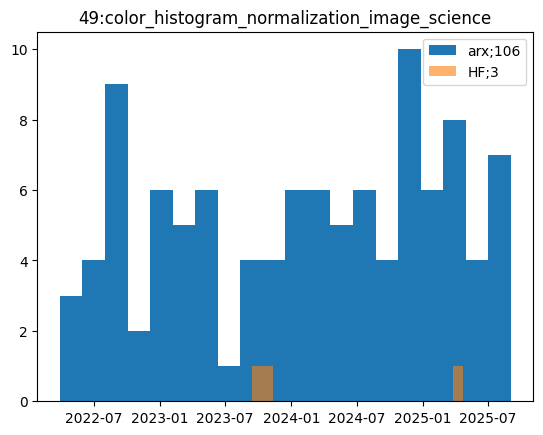

In [ ]:
for topic_nr in range(-1, max(topics)+1):
    plot_topic(topic_nr, k=3, min_examples=15)  
    

In [ ]:
max(topics)

135